In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os
import tensorflow.keras as kr
import numpy as np
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D , Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [19]:
path , dir , files = next(os.walk("/content/drive/MyDrive/Datasets/Brain_Data_Organised/Stroke"))
file_count = len(files)
print(f"Stroke: {file_count}")

Stroke: 950


In [20]:
path , dir , files = next(os.walk("/content/drive/MyDrive/Datasets/Brain_Data_Organised/Normal"))
file_count = len(files)
print(f"Normal: {file_count}")

Normal: 1551


In [21]:
image_size = (224 , 224)
batch_size = 32

train_df = kr.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Datasets/Brain_Data_Organised/train",
    validation_split = 0.20,
    subset = "training",
    seed = 1337,
    image_size = image_size,
    batch_size = batch_size
)

val_df = kr.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Datasets/Brain_Data_Organised/train",
    validation_split = 0.20,
    subset = "validation",
    seed = 1337,
    image_size = image_size,
    batch_size = batch_size
)

test_df =  kr.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Datasets/Brain_Data_Organised/test",
    image_size = image_size,
    batch_size = batch_size,
    shuffle = False
)

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 2000 files belonging to 2 classes.
Using 400 files for validation.
Found 501 files belonging to 2 classes.


In [22]:
y_test = np.concatenate([y for x , y in test_df] , axis=0)

In [23]:
train_df = train_df.prefetch(buffer_size=32)
val_df = val_df.prefetch(buffer_size=32)

In [24]:
imag_ind = 224
imag_shap = (imag_ind , imag_ind , 3)
loss = BinaryCrossentropy()
image_size = (224 , 224)
seed = 2
batch_size = 16

In [25]:
def get_callback(model_name):
    callbacks = []

    checkpoin = kr.callbacks.ModelCheckpoint(
        filepath=f"/content/drive/MyDrive/Projects/stroke classification project/model.{model_name}.keras",
        verbose=1,
        monitor='val_loss'
    )
    callbacks.append(checkpoin)

    anne = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=2,
        min_delta=0.00001,
        min_lr=0.0000000001
    )
    callbacks.append(anne)

    earlystop = kr.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10
    )

    return callbacks

In [26]:
optimizer = Adam(learning_rate=0.001)

# Input
inputs = kr.Input(shape=imag_shap)

# DenseNet121
base_model = kr.applications.DenseNet121(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs
)

base_model.trainable = True

# Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation="sigmoid")(x)

# Final Model
model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 6,954,881 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [28]:
callbacks = get_callback('dens121')
history = model.fit(
    train_df ,
    epochs = 50 ,
    validation_data = val_df,
    callbacks = callbacks
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6768 - loss: 0.6719
Epoch 1: saving model to /content/drive/MyDrive/Projects/stroke classification project/model.dens121.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Projects/stroke classification project/model.dens121.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 409s 4s/step - accuracy: 0.7325 - loss: 0.5602 - val_accuracy: 0.4000 - val_loss: 7.3295 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.8340 - loss: 0.3692
Epoch 2: saving model to /content/drive/MyDrive/Projects/stroke classification project/model.dens121.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Projects/stroke classification project/model.dens121.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 400ms/step - accuracy: 0.8500 - loss: 0.3458 - val_accuracy: 0.4950 - val_loss: 10.6522 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.8843 - loss: 0.2895
Epoch 3: savin

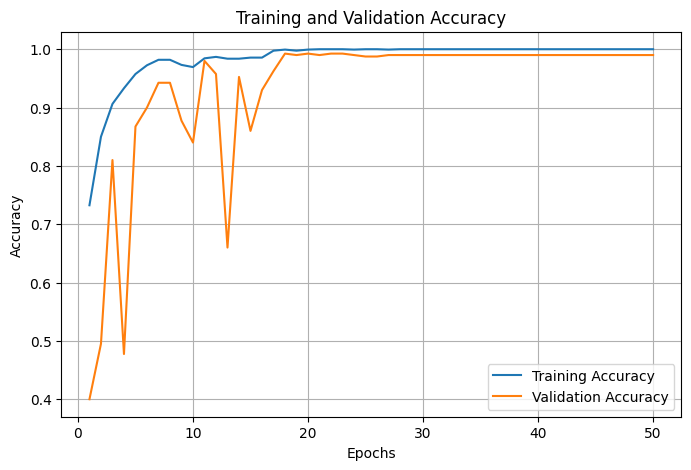

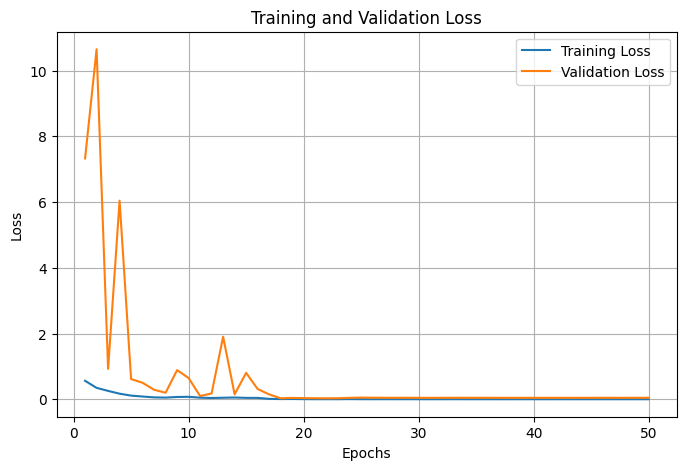

In [29]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Train and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Train and validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
model.evaluate(test_df)

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9920 - loss: 0.0301


[0.03010399453341961, 0.9920159578323364]

In [34]:
y_prob = model.predict(test_df)
y_pred = (y_prob >= 0.25).astype(int)
y_pred = y_pred.flatten()
print(classification_report(y_test , y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       311
           1       0.99      0.99      0.99       190

    accuracy                           0.99       501
   macro avg       0.99      0.99      0.99       501
weighted avg       0.99      0.99      0.99       501



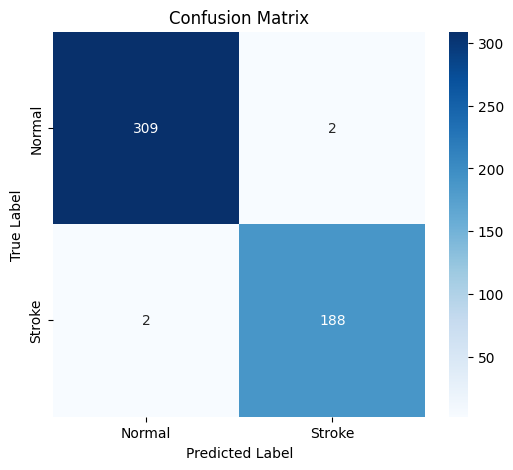

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Stroke'],
            yticklabels=['Normal', 'Stroke'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()